In [1]:
# @title Setup smoke test (run this once at home before the tutorial!)
try:
    from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache  # noqa
    import ssm  # noqa
    print("✅ Setup complete.")
except Exception as e:
    print("❌ Setup FAILED:", e)
    raise

/Users/kchen/Workspace/ccnss2026-neural-data-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete.


# CCNSS 2026 — Session 1: Coding and Networks

**Theme:** From single-neuron coding to network interactions.

We will analyze one Allen Visual Coding Neuropixels session in three modules:
- **1A** — Tuning curves and PSTHs
- **1B** — Signal and noise correlations
- **1C** — Functional networks and graph theory

**Time budget:** 45 minutes. Each module: ~5 min intro → 5–8 min exercise → 2 min reveal.

In [2]:
# @title Setup (run once) { display-mode: "form" }
import sys
# sys.path.insert(0, "/content/ccnss2026-neural-data-analysis")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ccnss_helpers import data, plotting, save_checkpoint, load_or_compute

print("✅ Setup complete.")

✅ Setup complete.


In [3]:
# Loads ~2 GB Allen NWB on first run (~3-5 min). Subsequent cells re-use the cache.
session = data.load_allen_session(session_id=715093703, cache_dir='~/.ccnss_cache/allen_cache/')
print(f"Session {session['session_id']}: {len(session['units'])} good units across "
      f"{session['units']['ecephys_structure_acronym'].nunique()} areas")
session["units"].groupby("ecephys_structure_acronym").size()

Session 715093703: 870 good units across 14 areas


ecephys_structure_acronym
APN       25
CA1      140
CA3       14
DG        24
LGd       82
LP       139
PO        76
PoT        1
VISam     30
VISl      37
VISp      60
VISpm     50
VISrl     75
grey     117
dtype: int64

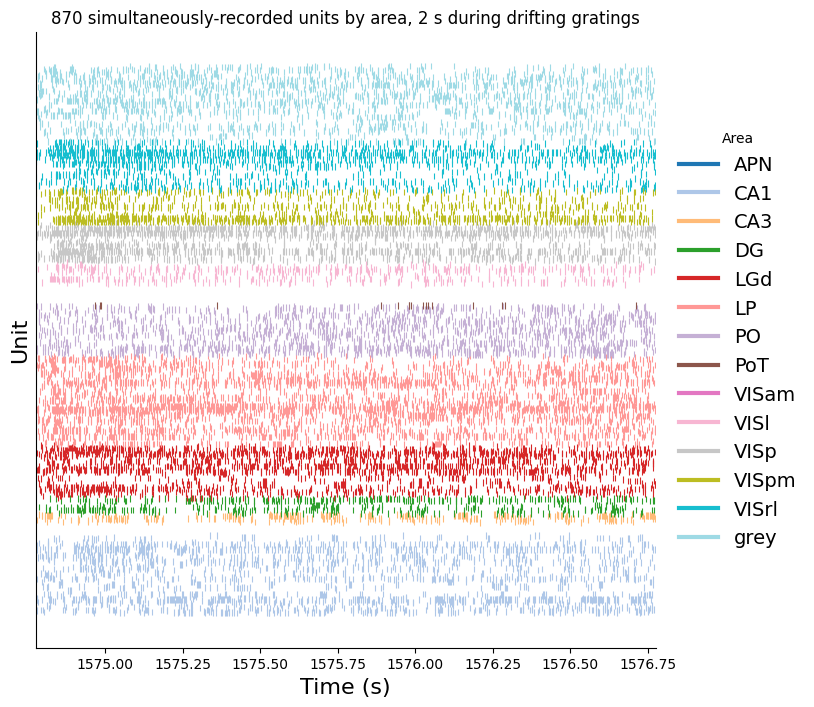

In [ ]:
# Visualize all simultaneously-recorded units for 5 s during drifting gratings,
# coloring each unit by the brain area it was recorded from. Units are sorted by
# area so same-area units form contiguous colored blocks in the raster.
areas = session["units"]["ecephys_structure_acronym"].fillna("unknown")
sample_uids = areas.sort_values().index
sample_spikes = {uid: session["spike_times"][uid] for uid in sample_uids}

unique_areas = list(dict.fromkeys(areas[sample_uids]))  # in plotted (sorted) order
palette = plt.cm.tab20(np.linspace(0, 1, len(unique_areas)))
area_to_color = dict(zip(unique_areas, palette))
unit_colors = {uid: area_to_color[areas[uid]] for uid in sample_uids}

t0 = session["stim_table"]["start_time"].iloc[0]
fig, ax = plt.subplots(figsize=(8, 8))
plotting.plot_raster(sample_spikes, t_start=t0, t_end=t0 + 2, colors=unit_colors, ax=ax)
ax.set_yticks([])
ax.spines[["top", "right"]].set_visible(False)

handles = [plt.Line2D([0], [0], color=area_to_color[a], lw=3) for a in unique_areas]
ax.legend(handles, unique_areas, title="Area", loc="center left",
          bbox_to_anchor=(1.01, 0.5), fontsize=14, frameon=False)
ax.set_title(f"{len(sample_uids)} simultaneously-recorded units by area, "
             "2 s during drifting gratings");


## Module 1A — Tuning curves & PSTHs

**Goal:** for each unit, compute how its firing rate depends on grating orientation.
Then find the most orientation-selective neuron in the population.

**Steps:**
1. Bin spikes into a (n_units × n_trials × n_bins) array aligned to stimulus onset.
2. For each unit, compute mean rate per orientation → tuning curve.
3. Compute the orientation selectivity index (OSI) (Niell and Stryker, 2008):

    $$\mathrm{OSI} = \frac{R_{\text{pref}} - R_{\text{orth}}}{R_{\text{pref}} + R_{\text{orth}}}$$

    or global OSI (Kuo, Gardner and Merriam, 2026):

    $$\mathrm{OSI}_{\text{global}} = \frac{\left|\sum R(\theta) e^{2i\theta}\right|}{\sum R(\theta)}$$

In [23]:
def bin_spikes_per_trial(spike_times_dict, stim_table, bin_size_s=0.025, window_s=(0.0, 2.0)):
    """Return (n_units, n_trials, n_bins) spike counts aligned to trial start_time."""
    uids = list(spike_times_dict.keys())
    bin_edges = np.arange(window_s[0], window_s[1] + bin_size_s, bin_size_s)
    n_bins = len(bin_edges) - 1
    n_trials = len(stim_table)
    counts = np.zeros((len(uids), n_trials, n_bins), dtype=np.int32)
    for i, uid in enumerate(uids):
        st = spike_times_dict[uid]
        for j, t0 in enumerate(stim_table["start_time"].to_numpy()):
            rel = st - t0
            mask = (rel >= window_s[0]) & (rel < window_s[1])
            counts[i, j, :] = np.histogram(rel[mask], bins=bin_edges)[0]
    return counts, bin_edges, uids

counts, bin_edges, uids = bin_spikes_per_trial(
    session["spike_times"], session["stim_table"]
)
print(counts.shape)  # expected: (n_units, n_trials, n_bins)

(870, 598, 80)


In [24]:
def compute_tuning_curves(counts, stim_table, bin_size_s=0.025):
    """Mean firing rate per (unit, orientation). Returns (orientations, rates[n_units, n_oris])."""
    rates_per_trial = counts.sum(axis=2) / (counts.shape[2] * bin_size_s)  # Hz
    oris = np.sort(stim_table["orientation"].dropna().unique())
    tc = np.zeros((counts.shape[0], len(oris)))
    for k, ori in enumerate(oris):
        mask = stim_table["orientation"].to_numpy() == ori
        tc[:, k] = rates_per_trial[:, mask].mean(axis=1)
    return oris, tc

oris, tc = compute_tuning_curves(counts, session["stim_table"])
print(tc.shape)

(870, 8)


In [52]:
session["stim_table"]

,stimulus_block,start_time,stop_time,contrast,spatial_frequency,phase,temporal_frequency,frame,y_position,size,stimulus_name,color,x_position,orientation,duration,stimulus_condition_id
stimulus_presentation_id,,,,,,,,,,,,,,,,
3798,2.0,1574.774823,1576.776513,0.8,0.04,"[21211.93333333, 21211.93333333]",4.0,null,null,"[250.0, 250.0]",drifting_gratings,null,null,315.0,2.00169,246
3799,2.0,1577.777347,1579.779027,0.8,0.04,"[21211.93333333, 21211.93333333]",8.0,null,null,"[250.0, 250.0]",drifting_gratings,null,null,90.0,2.00168,247
3800,2.0,1580.779833,1582.781563,0.8,0.04,"[21211.93333333, 21211.93333333]",2.0,null,null,"[250.0, 250.0]",drifting_gratings,null,null,225.0,2.00173,248
3801,2.0,1583.782367,1585.784047,0.8,0.04,"[21211.93333333, 21211.93333333]",2.0,null,null,"[250.0, 250.0]",drifting_gratings,null,null,90.0,2.00168,249
3802,2.0,1586.784883,1588.786553,0.8,0.04,"[21211.93333333, 21211.93333333]",8.0,null,null,"[250.0, 250.0]",drifting_gratings,null,null,135.0,2.00167,250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49426,7.0,5366.976107,5368.977777,0.8,0.04,"[21211.93333333, 21211.93333333]",15.0,null,null,"[250.0, 250.0]",drifting_gratings,null,null,135.0,2.00167,274
49427,7.0,5369.978603,5371.980283,0.8,0.04,"[21211.93333333, 21211.93333333]",8.0,null,null,"[250.0, 250.0]",drifting_gratings,null,null,180.0,2.00168,260
49428,7.0,5372.981107,5374.982807,0.8,0.04,"[21211.93333333, 21211.93333333]",1.0,null,null,"[250.0, 250.0]",drifting_gratings,null,null,0.0,2.00170,251


Most selective unit: 950932696 (OSI=0.82, area=VISp)


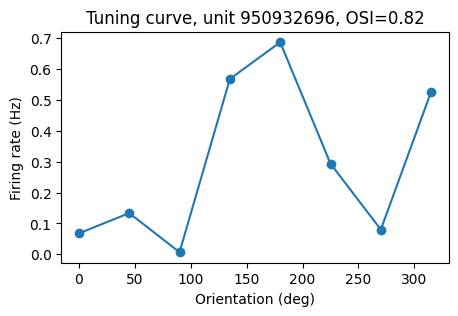

In [35]:
# EXERCISE: compute OSI for every unit and find the most selective one
def osi(tc_row):
    """Orientation Selectivity Index for one tuning curve row."""
    pref = tc_row.max()
    pref_idx = tc_row.argmax()
    orth_idx = (pref_idx + len(tc_row) // 2) % len(tc_row)
    orth = tc_row[orth_idx]
    return (pref - orth) / (pref + orth + 1e-9)

osis = np.array([osi(row) for row in tc])
best = osis.argmax()
print(f"Most selective unit: {uids[best]} (OSI={osis[best]:.2f}, area={session['units'].loc[uids[best], 'ecephys_structure_acronym']})")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(oris, tc[best], "o-")
ax.set_xlabel("Orientation (deg)"); ax.set_ylabel("Firing rate (Hz)")
ax.set_title(f"Tuning curve, unit {uids[best]}, OSI={osis[best]:.2f}");

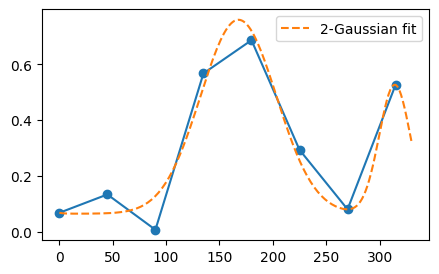

In [40]:
# CUTTABLE: two-component Gaussian mixture tuning fit
from scipy.optimize import curve_fit

def _ang_dist(x_deg, mu):
    """Signed angular distance in degrees, wrapped to [-180, 180)."""
    return (x_deg - mu + 180) % 360 - 180

def two_gaussian_mixture(x_deg, a1, mu1, s1, a2, mu2, s2, offset):
    """Sum of two circular Gaussians: a preferred direction plus its 180 deg anti-peak."""
    g1 = a1 * np.exp(-0.5 * (_ang_dist(x_deg, mu1) / s1) ** 2)
    g2 = a2 * np.exp(-0.5 * (_ang_dist(x_deg, mu2) / s2) ** 2)
    return g1 + g2 + offset

pref = oris[tc[best].argmax()]
p0 = [tc[best].max(), pref, 25.0,
      0.5 * tc[best].max(), (pref + 180) % 360, 25.0,
      tc[best].min()]
popt, _ = curve_fit(two_gaussian_mixture, oris, tc[best], p0=p0, maxfev=10000)

xs = np.linspace(0, 330, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(oris, tc[best], "o-")
ax.plot(xs, two_gaussian_mixture(xs, *popt), "--", label="2-Gaussian fit")
ax.legend()

In [46]:
oris.astype(float)

array([  0.,  45.,  90., 135., 180., 225., 270., 315.])

In [59]:
# Orientation selectivity index (OSI) for this neuron, unit uids[best].
# Orientation is 180-deg periodic, so the null response is the *orthogonal*
# orientation (90 deg away) -- NOT the opposite drift direction (180 deg away,
# which is the SAME orientation).
tc_row = tc[best]
d_ori = np.diff(oris).min()                       # spacing between sampled directions (deg)
pref_idx = tc_row.argmax()
orth_idx = (pref_idx + int(round(90 / d_ori))) % len(tc_row)
R_pref, R_orth = tc_row[pref_idx], tc_row[orth_idx]
osi_pref_orth = (R_pref - R_orth) / (np.abs(R_pref) + np.abs(R_orth) + 1e-9)

# Global (vector-average) OSI over the full tuning curve; the 2*theta makes it
# 180-deg periodic, and it uses every orientation so it is less noise-sensitive.
theta = np.deg2rad(oris.astype(float))
osi_global = np.abs(np.sum(tc_row * np.exp(2j * theta))) / (np.sum(tc_row) + 1e-9)

area = session["units"].loc[uids[best], "ecephys_structure_acronym"]
print(f"Unit {uids[best]} ({area}):")
print(f"  pref dir = {oris[pref_idx]} deg, orthogonal dir = {oris[orth_idx]} deg")
print(f"  OSI (pref vs orthogonal) = {osi_pref_orth:.2f}")
print(f"  OSI (global) = {osi_global:.2f}")

Unit 950932696 (VISp):
  pref dir = 180.0 deg, orthogonal dir = 270.0 deg
  OSI (pref vs orthogonal) = 0.79
  OSI (global) = 0.40


Exercise: compute OSI for each unit and investigate the distribution of OSI and preferred orientations across the brain areas.

In [58]:
# code for exercise:

array([0.06756757, 0.13333333, 0.00666667, 0.56756757, 0.68666667,
       0.29333333, 0.08      , 0.52666667])

In [10]:
save_checkpoint(
    "module_1A",
    counts=counts,
    bin_edges=bin_edges,
    uids=np.asarray(uids),
    oris=oris,
    tc=tc,
    osis=osis,
)
print("✅ 1A checkpoint saved.")

✅ 1A checkpoint saved.


## Module 1B — Signal and noise correlations

For each pair of neurons (i, j):
- **Signal correlation:** corr of their tuning curves across orientations.
- **Noise correlation:** corr of their trial-to-trial responses at a fixed orientation, averaged across orientations.

Recreate the canonical Cohen & Kohn 2011 scatter plot: r_signal on x, r_noise on y.

In [61]:
ck = load_or_compute(
    "module_1A",
    fn=lambda: {"error": np.array([1])},  # If we get here in 1B, 1A must have run.
)
counts, oris, tc, uids = ck["counts"], ck["oris"], ck["tc"], list(ck["uids"])

In [62]:
def signal_correlation_matrix(tc):
    """Pearson r of tuning curves between all unit pairs."""
    return np.corrcoef(tc)

r_signal = signal_correlation_matrix(tc)
print(r_signal.shape)

(870, 870)


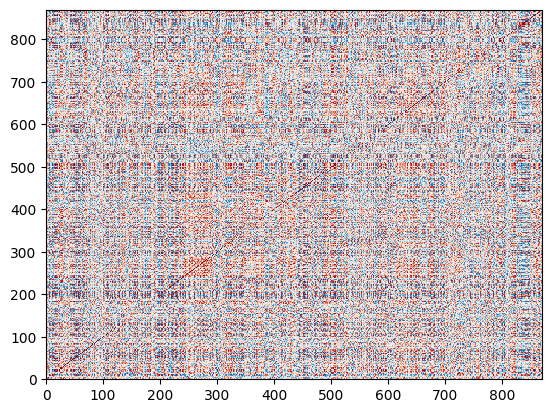

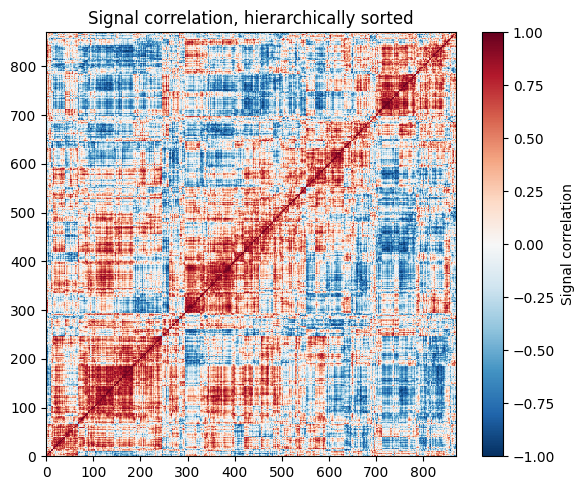

In [64]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

plt.pcolormesh(r_signal, cmap="RdBu_r", vmin=-1, vmax=1)
dist = 1 - r_signal
np.fill_diagonal(dist, 0.0)
order = leaves_list(linkage(squareform(dist, checks=False), method="average"))
r_signal_sorted = r_signal[np.ix_(order, order)]

plt.figure(figsize=(6, 5))
plt.pcolormesh(r_signal_sorted, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="Signal correlation")
plt.title("Signal correlation, hierarchically sorted")
plt.tight_layout()

In [13]:
# EXERCISE: compute the noise-correlation matrix
def noise_correlation_matrix(counts, stim_table, bin_size_s=0.025):
    """Mean-across-orientations Pearson r of trial-to-trial residual rates."""
    rates = counts.sum(axis=2) / (counts.shape[2] * bin_size_s)  # n_units x n_trials
    rs = []
    for ori in np.sort(stim_table["orientation"].dropna().unique()):
        mask = stim_table["orientation"].to_numpy() == ori
        z = (rates[:, mask] - rates[:, mask].mean(axis=1, keepdims=True))
        # Avoid divide-by-zero for silent units.
        std = rates[:, mask].std(axis=1, keepdims=True) + 1e-9
        z = z / std
        rs.append(z @ z.T / mask.sum())
    return np.mean(rs, axis=0)

r_noise = noise_correlation_matrix(counts, session["stim_table"])

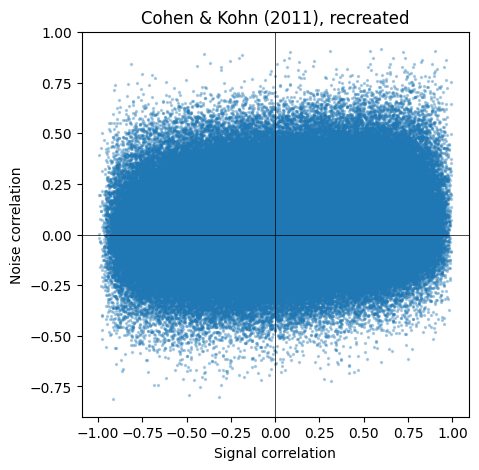

In [14]:
# EXERCISE: make the signal-vs-noise scatter
iu = np.triu_indices_from(r_signal, k=1)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(r_signal[iu], r_noise[iu], s=2, alpha=0.3)
ax.set_xlabel("Signal correlation"); ax.set_ylabel("Noise correlation")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_title("Cohen & Kohn (2011), recreated");

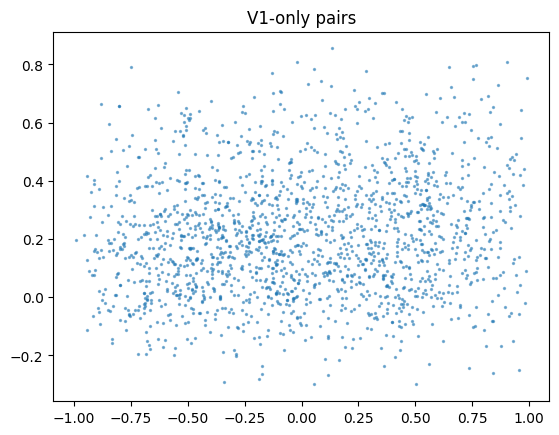

In [15]:
# CUTTABLE: signal-vs-noise scatter, restricted to within-area pairs in V1
v1_idx = [i for i, u in enumerate(uids) if session["units"].loc[u, "ecephys_structure_acronym"] == "VISp"]
sub_iu = np.array([(i, j) for a, i in enumerate(v1_idx) for j in v1_idx[a+1:]]).T
plt.scatter(r_signal[sub_iu[0], sub_iu[1]], r_noise[sub_iu[0], sub_iu[1]], s=2, alpha=0.5)
plt.title("V1-only pairs");

In [16]:
save_checkpoint("module_1B", r_signal=r_signal, r_noise=r_noise, uids=np.asarray(uids))
print("✅ 1B checkpoint saved.")

✅ 1B checkpoint saved.


## Module 1C — Functional networks & graph theory

We treat each unit as a node and connect pairs whose noise correlation exceeds a threshold.

Then we investigate the several properties of the functional networks:
- Degree
- Clustering coefficient
- Modularity
- (challenge) Communities

In [65]:
ck = load_or_compute("module_1B", fn=lambda: {"error": np.array([1])})
r_noise = ck["r_noise"]; uids = list(ck["uids"])
units_meta = session["units"].loc[uids]

In [66]:
# EXERCISE: build the adjacency graph from r_noise
import networkx as nx

def build_graph(r, threshold=0.1):
    A = (np.abs(r) > threshold).astype(int)
    np.fill_diagonal(A, 0)
    return nx.from_numpy_array(A)

G = build_graph(r_noise, threshold=0.1)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 870 nodes, 197770 edges


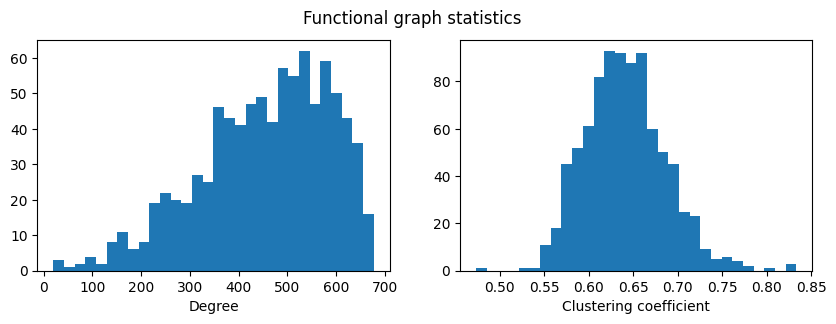

In [67]:
# EXERCISE: compute degree + clustering, plot histograms
deg = np.array([G.degree(i) for i in range(len(uids))])
clust = np.array([nx.clustering(G, i) for i in range(len(uids))])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(deg, bins=30); axes[0].set_xlabel("Degree")
axes[1].hist(clust, bins=30); axes[1].set_xlabel("Clustering coefficient")
plt.suptitle("Functional graph statistics");

In [68]:
hub_idx = deg.argsort()[-5:][::-1]
print("Top 5 hubs:")
for i in hub_idx:
    print(f"  unit {uids[i]} ({units_meta.iloc[i]['ecephys_structure_acronym']}): degree={deg[i]}")

# Density per area
for area, ar in units_meta.groupby("ecephys_structure_acronym"):
    idx = [uids.index(u) for u in ar.index]
    sub = G.subgraph(idx)
    print(f"{area}: density={nx.density(sub):.3f} ({sub.number_of_nodes()} units)")

Top 5 hubs:
  unit 950929227 (CA1): degree=677
  unit 950936870 (CA3): degree=675
  unit 950938924 (CA1): degree=671
  unit 950949449 (DG): degree=670
  unit 950919676 (VISpm): degree=670
APN: density=0.883 (25 units)
CA1: density=0.579 (140 units)
CA3: density=0.769 (14 units)
DG: density=0.594 (24 units)
LGd: density=0.686 (82 units)
LP: density=0.630 (139 units)
PO: density=0.772 (76 units)
PoT: density=0.000 (1 units)
VISam: density=0.733 (30 units)
VISl: density=0.505 (37 units)
VISp: density=0.727 (60 units)
VISpm: density=0.540 (50 units)
VISrl: density=0.459 (75 units)
grey: density=0.452 (117 units)


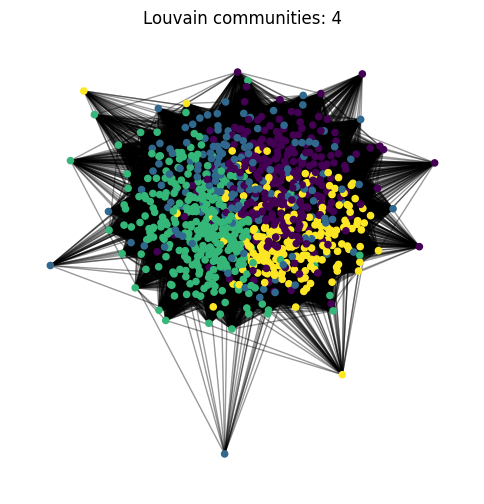

In [69]:
# CUTTABLE: Louvain community detection + overlay vs anatomical area
from networkx.algorithms.community import louvain_communities
comms = louvain_communities(G, seed=0)
labels = np.zeros(len(uids), dtype=int)
for c, members in enumerate(comms):
    for m in members:
        labels[m] = c
plotting.plot_network(G, node_color=labels, node_size=20)
plt.title(f"Louvain communities: {len(comms)}");

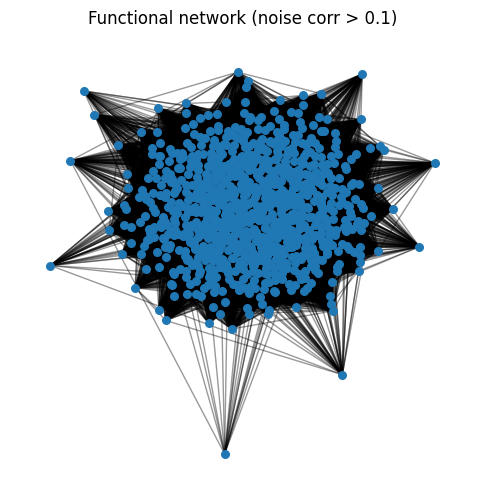

In [70]:
plotting.plot_network(G)
plt.title("Functional network (noise corr > 0.1)");